In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
forex_data = pd.read_csv("Technical_Data/forex_with_indicators.csv")

In [15]:
forex_data["DateTime"] = pd.to_datetime(forex_data["DateTime"])

In [16]:
forex_data.head()

,DateTime,PairID,PairName,Open,High,Low,Close,Volume,Spread,SMA_10,SMA_20,EMA_10,RSI,MACD,Signal_Line,Middle_Band,Upper_Band,Lower_Band
0,2023-01-01 00:00:00,1,EUR/USD,1.08103,1.08103,1.08019,1.08054,2651,0.9,NaN,NaN,1.080540,NaN,0.000000,0.000000,NaN,NaN,NaN
1,2023-01-01 01:00:00,1,EUR/USD,1.08010,1.08043,1.07974,1.08028,2292,1.0,NaN,NaN,1.080493,NaN,-0.000021,-0.000004,NaN,NaN,NaN
2,2023-01-01 02:00:00,1,EUR/USD,1.08036,1.08158,1.07961,1.08054,1796,1.2,NaN,NaN,1.080501,NaN,-0.000016,-0.000007,NaN,NaN,NaN
3,2023-01-01 03:00:00,1,EUR/USD,1.08068,1.08126,1.07973,1.08088,4019,1.4,NaN,NaN,1.080570,NaN,0.000015,-0.000002,NaN,NaN,NaN
4,2023-01-01 04:00:00,1,EUR/USD,1.08042,1.08042,1.07967,1.08030,2207,1.6,NaN,NaN,1.080521,NaN,-0.000007,-0.000003,NaN,NaN,NaN


In [17]:
forex_data["Signal"] = "HOLD"

In [18]:
forex_data.loc[
    (forex_data["SMA_10"] > forex_data["SMA_20"]) &
    (forex_data["RSI"] < 70) &
    (forex_data["MACD"] > forex_data["Signal_Line"]),
    "Signal"
] = "BUY"

In [19]:
forex_data.loc[
    (forex_data["SMA_10"] < forex_data["SMA_20"]) &
    (forex_data["RSI"] > 30) &
    (forex_data["MACD"] < forex_data["Signal_Line"]),
    "Signal"
] = "SELL"

In [20]:
print(forex_data["Signal"].value_counts())

Signal
HOLD    242
BUY     155
SELL    103
Name: count, dtype: int64


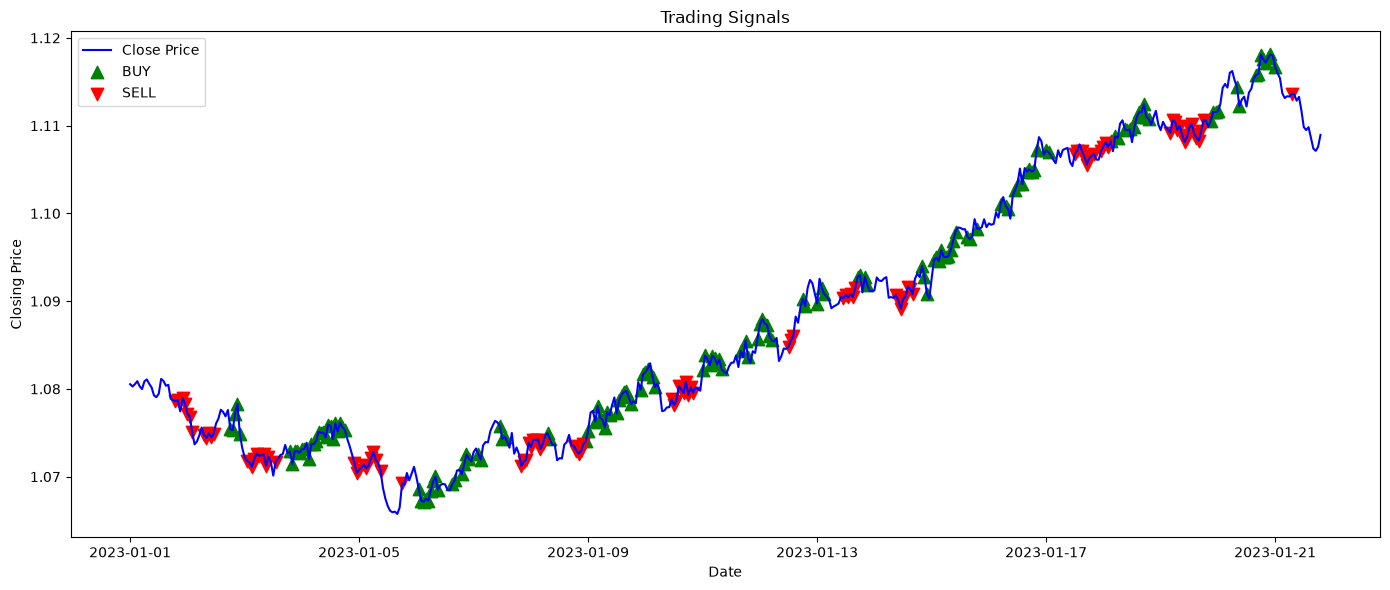

In [21]:
plt.figure(figsize=(14,6))

plt.plot(
    forex_data["DateTime"],
    forex_data["Close"],
    label="Close Price",
    color="blue"
)

buy = forex_data[forex_data["Signal"] == "BUY"]
sell = forex_data[forex_data["Signal"] == "SELL"]

plt.scatter(
    buy["DateTime"],
    buy["Close"],
    marker="^",
    color="green",
    s=80,
    label="BUY"
)

plt.scatter(
    sell["DateTime"],
    sell["Close"],
    marker="v",
    color="red",
    s=80,
    label="SELL"
)

plt.title("Trading Signals")

plt.xlabel("Date")

plt.ylabel("Closing Price")

plt.legend()

plt.tight_layout()

plt.show()

In [22]:
forex_data[
    ["DateTime", "Close", "SMA_10", "SMA_20", "RSI", "MACD", "Signal_Line", "Signal"]
].head(20)

,DateTime,Close,SMA_10,SMA_20,RSI,MACD,Signal_Line,Signal
0,2023-01-01 00:00:00,1.08054,NaN,NaN,NaN,0.000000,0.000000,HOLD
1,2023-01-01 01:00:00,1.08028,NaN,NaN,NaN,-0.000021,-0.000004,HOLD
2,2023-01-01 02:00:00,1.08054,NaN,NaN,NaN,-0.000016,-0.000007,HOLD
3,2023-01-01 03:00:00,1.08088,NaN,NaN,NaN,0.000015,-0.000002,HOLD
4,2023-01-01 04:00:00,1.08030,NaN,NaN,NaN,-0.000007,-0.000003,HOLD
5,2023-01-01 05:00:00,1.07998,NaN,NaN,NaN,-0.000050,-0.000013,HOLD
6,2023-01-01 06:00:00,1.08087,NaN,NaN,NaN,-0.000012,-0.000012,HOLD
7,2023-01-01 07:00:00,1.08108,NaN,NaN,NaN,0.000035,-0.000003,HOLD
8,2023-01-01 08:00:00,1.08058,NaN,NaN,NaN,0.000031,0.000004,HOLD
9,2023-01-01 09:00:00,1.08017,1.080522,NaN,NaN,-0.000005,0.000002,HOLD


In [23]:
forex_data.to_csv(
    "Signal_Data/forex_with_signals.csv",
    index=False
)

In [24]:
import os

print(os.listdir("Signal_Data"))

['forex_with_signals.csv']
